<a href="https://colab.research.google.com/github/idan8618-lang/Data-Science-HW1/blob/main/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Load the car sales dataset

import pandas as pd

car_sales_df = pd.read_csv('Car Sales.xlsx - car_data.csv')

### Cross-Validation

I used 5-fold cross-validation for the analysis.

The dataset has about 24,000 observations, so each fold still contains enough data for training and validation.

Using more folds would increase the computation time, especially for Random Forest.

I chose k=5 because it gives several different train/test splits without making the computation too heavy.

Using 5 folds also gives a reasonable balance between bias and variance.

# 1. Regression Error Analysis

## 1.1 Residual Analysis


In [2]:
# 1.1 Residual Analysis - Define target and features

y = car_sales_df['Price ($)']

X = car_sales_df[
    [
        'Annual Income',
        'Gender',
        'Company',
        'Model',
        'Engine',
        'Transmission',
        'Color',
        'Body Style',
        'Dealer_Region'
    ]
]

In [3]:
# 1.1 Residual Analysis - Import required libraries

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [4]:
# 1.1 Residual Analysis - Prepare numeric and categorical features

numeric_features = ['Annual Income']

categorical_features = [
    'Gender',
    'Company',
    'Model',
    'Engine',
    'Transmission',
    'Color',
    'Body Style',
    'Dealer_Region'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

In [5]:
# 1.1 Residual Analysis - Build Linear Regression model and generate predictions

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(model, X, y, cv=kf)

In [6]:
# 1.1 Residual Analysis - Calculate residuals

residuals = y - y_pred

### Tasks

#### Plot residuals as a function of predicted values

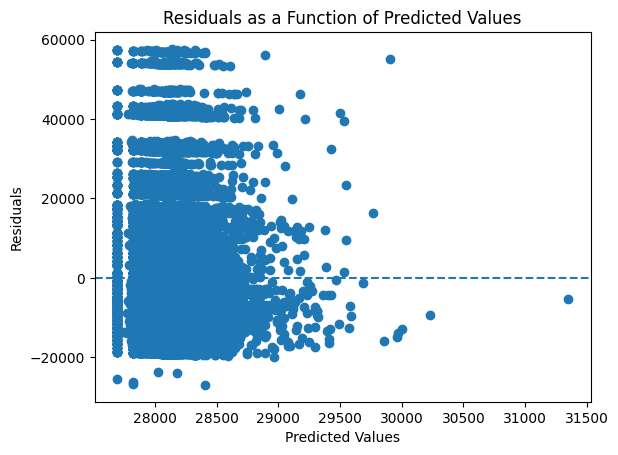

In [7]:
# 1.1 Residual Analysis - Tasks - Plot residuals as a function of predicted values

import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals as a Function of Predicted Values')

plt.show()

#### Plot the distribution of residuals (e.g., histogram)


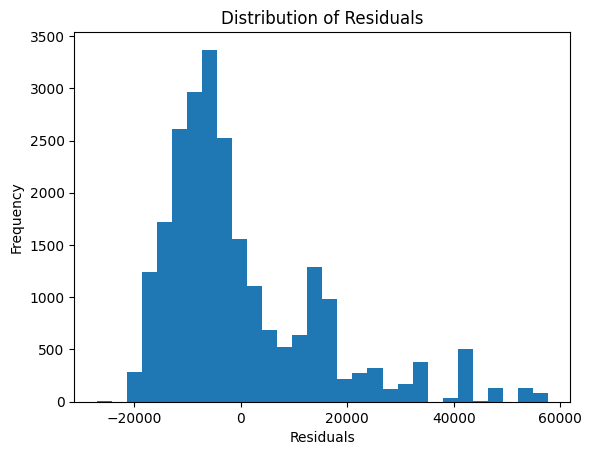

In [8]:
# 1.1 Residual Analysis - Tasks - Plot the distribution of residuals

plt.hist(residuals, bins=30)

plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

plt.show()

#### Are the residuals centered around zero?

The residuals are not exactly centered around zero. Many of them are negative, and the distribution is not symmetric. This suggests that the model has some bias and does not predict all car prices equally well.

------

#### Do the residuals exhibit any systematic patterns?

Yes. The residuals do not appear to be randomly scattered around zero. There is a clear concentration of points in some predicted-value ranges, and the spread of the residuals changes across the graph. This suggests that the linear regression model does not capture all the patterns in the data.

------

#### Is there evidence of heteroscedasticity (i.e., non-constant variance)?

Yes. The spread of the residuals is not constant across the predicted values. In some areas the residuals are more concentrated, while in others they are much more spread out. This suggests that there is evidence of heteroscedasticity.

------

#### Is there a sector that is more likely to have high error rates? If so, why do you think this is happening?

From the residual plot, cars with predicted prices in the middle-to-high range seem to have larger errors. The residuals in this area are more spread out compared to other ranges. This may happen because car prices depend on several factors and a linear model may not capture all of these relationships. A specific sector such as company or body style will be examined more closely in the next analysis.

------

## 1.2 Error as a Function of Features

### Tasks

#### Plot feature values versus residuals


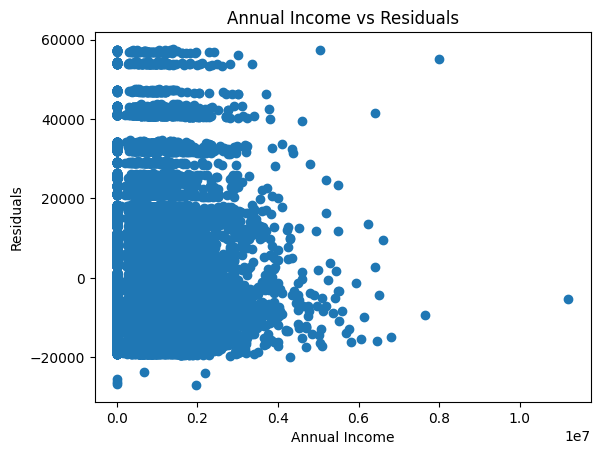

In [9]:
# 1.2 Error as a Function of Features - Tasks - Plot feature values versus residuals

plt.scatter(car_sales_df['Annual Income'], residuals)

plt.xlabel('Annual Income')
plt.ylabel('Residuals')
plt.title('Annual Income vs Residuals')

plt.show()

#### Plot feature values versus absolute errors

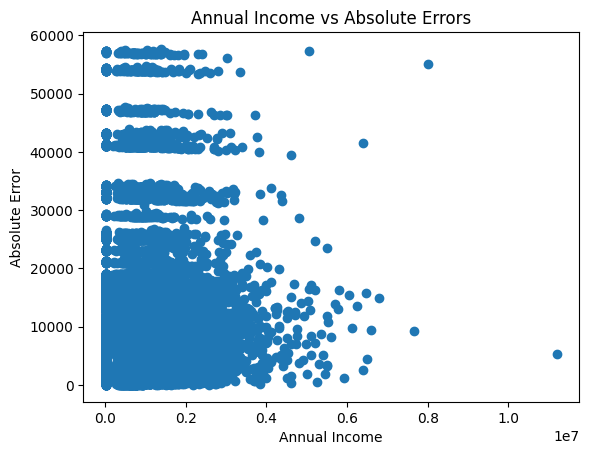

In [10]:
# 1.2 Error as a Function of Features - Tasks - Plot feature values versus absolute errors

absolute_errors = abs(residuals)

plt.scatter(car_sales_df['Annual Income'], absolute_errors)

plt.xlabel('Annual Income')
plt.ylabel('Absolute Error')
plt.title('Annual Income vs Absolute Errors')

plt.show()

#### Error patterns by Body Style

#### Plot feature values versus residuals - Body Style


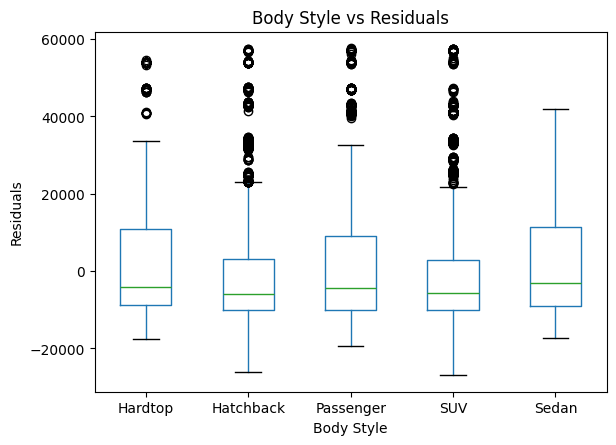

In [11]:
# 1.2 Error as a Function of Features - Tasks - Plot Body Style versus residuals

plot_df = pd.DataFrame({
    'Body Style': car_sales_df['Body Style'],
    'Residuals': residuals
})

plot_df.boxplot(column='Residuals', by='Body Style', grid=False)

plt.xlabel('Body Style')
plt.ylabel('Residuals')
plt.title('Body Style vs Residuals')
plt.suptitle('')

plt.show()

#### Plot feature values versus absolute errors - Body Style


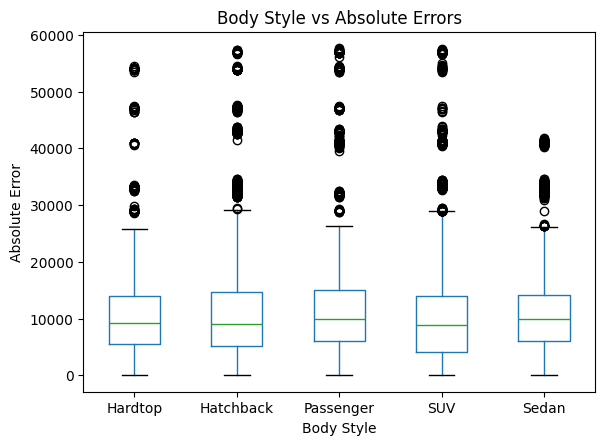

In [12]:
# 1.2 Error as a Function of Features - Tasks - Plot Body Style versus absolute errors

plot_df['Absolute Error'] = abs(residuals)

plot_df.boxplot(column='Absolute Error', by='Body Style', grid=False)

plt.xlabel('Body Style')
plt.ylabel('Absolute Error')
plt.title('Body Style vs Absolute Errors')
plt.suptitle('')

plt.show()

### Objective

#### Annual Income

From the plots, Annual Income does not seem to have a clear relationship with the model error. Most of the observations are concentrated in the lower and middle income ranges, and the errors are spread over a wide range.

This also connects to the EDA. The Price-to-Income ratio had a right-skewed distribution, with most values concentrated at the lower range and a few much larger values.

This suggests that the relationship between Annual Income and car price is not very simple, which fits with the fact that Annual Income did not show a clear pattern in the prediction errors.

------

------

#### Body Style

For Body Style, the differences between the categories are not very large. Passenger and Sedan cars have slightly higher typical absolute errors, while Hatchback, Passenger, and SUV contain several large outliers.

------

#### Additional Observations

Another thing that can be seen is that the residuals for most Body Style categories are slightly below zero, which means the model tends to overestimate the price in some cases. Overall, the model performs quite similarly across the different Body Style categories, but there are some specific observations where the prediction error is much larger.

------

### Summary and Conclusions

This suggests that Annual Income alone does not explain the model errors very well, while Body Style may have some effect on the error. The large outliers may also indicate that there are specific groups or unusual cars that the linear model does not capture well.

------

## 1.3 Analysis of Extreme Errors

### Tasks

#### Identify the top 5% largest absolute errors

In [13]:
# 1.3 Analysis of Extreme Errors - Tasks - Identify the top 5% largest absolute errors

car_sales_df['Residual'] = residuals
car_sales_df['Absolute Error'] = absolute_errors

threshold = car_sales_df['Absolute Error'].quantile(0.95)

extreme_errors = car_sales_df[
    car_sales_df['Absolute Error'] >= threshold
]

extreme_errors.head()


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Residual,Absolute Error
8,C_CND_000009,1/2/2022,Naomi,Male,815000,Rabun Used Car Sales,Chevrolet,Malibu,Overhead Camshaft,Manual,Pale White,82000,85257-3102,Hardtop,7194857,Pasco,53891.839776,53891.839776
37,C_CND_000038,1/3/2022,Haylee,Male,13500,Gartner Buick Hyundai Saab,Buick,Park Avenue,DoubleÂ Overhead Camshaft,Auto,Black,61000,38701-8047,Hatchback,7438037,Greenville,33307.200796,33307.200796
73,C_CND_000074,1/5/2022,Ingrid,Male,300000,Pitre Buick-Pontiac-Gmc of Scottsdale,Ford,Contour,DoubleÂ Overhead Camshaft,Auto,Pale White,62000,99301-3882,Sedan,7031644,Pasco,34192.470006,34192.470006
108,C_CND_000109,1/6/2022,Vanessa,Male,480000,Motor Vehicle Branch Office,Mercury,Grand Marquis,Overhead Camshaft,Manual,Pale White,71000,78758-7841,SUV,8884667,Middletown,43000.013968,43000.013968
111,C_CND_000112,1/9/2022,Isabelle,Male,700000,Scrivener Performance Engineering,Buick,Park Avenue,DoubleÂ Overhead Camshaft,Auto,Pale White,62001,38701-8047,Hatchback,6729016,Greenville,33898.605758,33898.605758


#### Analyze these observations individually


In [14]:
# 1.3 Analysis of Extreme Errors - Tasks - Analyze these observations individually

extreme_errors_sorted = extreme_errors.sort_values(
    by='Absolute Error',
    ascending=False
)

extreme_errors_sorted[
    [
        'Car_id',
        'Company',
        'Model',
        'Body Style',
        'Annual Income',
        'Price ($)',
        'Residual',
        'Absolute Error'
    ]
].head(10)

,Car_id,Company,Model,Body Style,Annual Income,Price ($),Residual,Absolute Error
7068,C_CND_007069,Cadillac,Eldorado,Passenger,1388000,85800,57663.110141,57663.110141
9228,C_CND_009229,Audi,A6,SUV,497500,85500,57495.579206,57495.579206
13605,C_CND_013606,Cadillac,Eldorado,Passenger,1036000,85600,57460.189337,57460.189337
358,C_CND_000359,Toyota,RAV4,Hatchback,1326000,85600,57368.637419,57368.637419
11330,C_CND_011331,Cadillac,Eldorado,Passenger,1185000,85500,57321.356432,57321.356432
6530,C_CND_006531,Mercedes-B,S-Class,SUV,392250,85250,57313.418810,57313.418810
18952,C_CND_018953,Mercedes-B,S-Class,SUV,13500,85001,57308.200796,57308.200796
1973,C_CND_001974,Audi,A6,SUV,13500,85000,57307.200796,57307.200796
23024,C_CND_023025,Mercedes-B,S-Class,SUV,13500,85000,57307.200796,57307.200796
6850,C_CND_006851,Mercedes-B,S-Class,SUV,13500,85000,57307.200796,57307.200796


### Discussion

#### Data quality issues

There is no clear evidence that these errors are caused by incorrect data. Similar high prices appear for several different cars, so the values do not look like simple input mistakes.

------

#### Model limitations

The large errors are more likely related to limitations of the linear regression model. Car prices may depend on complex and non-linear relationships between features, especially for expensive cars. A linear model may not be able to represent these relationships well.

------

#### Rare or exceptional cases

Many of the extreme errors appear in expensive cars, such as Cadillac Eldorado, Audi A6, and Mercedes-Benz S-Class. These cars may represent more unusual cases in the dataset, which can make them harder for the model to predict accurately.

The EDA also showed a small number of extreme observations in the Price-to-Income ratio.

This supports the idea that the dataset contains some unusual cases, which may also be more difficult for the model to predict correctly.

------

### Summary and Conclusions

The extreme error analysis shows that the model has more difficulty predicting some of the most expensive cars. In these cases, the residuals are large and positive, which means that the model predicts a much lower price than the actual price.

The main reason seems to be a limitation of the linear regression model rather than an obvious problem with the data. The results also suggest that expensive or unusual cars form a group where the model performs worse.

Overall, this analysis shows that the model does not perform equally well for all cars, and a more flexible model may be able to predict these extreme cases better.

------

## 1.4 Statistical Properties of Errors

### Compute

In [15]:
# 1.4 Statistical Properties of Errors - Compute error statistics

mae = absolute_errors.mean()
std_residuals = residuals.std()
skewness = residuals.skew()
kurtosis = residuals.kurt()

print("MAE:", mae)
print("Standard deviation of residuals:", std_residuals)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

MAE: 11283.737083762642
Standard deviation of residuals: 14790.378304083495
Skewness: 1.466565634263933
Kurtosis: 2.0092368082721164


### Interpretation

### Mean Absolute Error (MAE)

The MAE is about 11,283 USD. This means that, on average, the predicted car price differs from the actual price by about 11,283 USD.

------

### Standard deviation of residuals

The standard deviation of the residuals is about 14,790 USD. This shows that the prediction errors are quite spread out, which means that the size of the error can vary significantly between cars.

------

### Skewness

The skewness is 1.47, which is positive. This means that the residual distribution is skewed to the right. There are some large positive residuals, meaning that in some cases the model predicts a price that is much lower than the actual price.

------

### Kurtosis

The kurtosis is about 2.01. Since the value is positive, the residual distribution has heavier tails than a normal distribution. This agrees with the extreme errors found in the previous section and shows that there are some unusually large prediction errors.

------

### Summary and Conclusions

The statistical analysis shows that the model has an average error of about 11,283 USD, but the errors can vary considerably. The positive skewness shows that some cars have much larger positive residuals, especially when the model underestimates their prices.

The positive kurtosis also supports what we saw in the previous plots and in the extreme error analysis: there are several large errors in the dataset. Overall, the results suggest that the linear regression model does not perform equally well for all cars and has difficulty with some unusual or high-priced cases.

------

# 2. Regression Models



### Model Settings

The default hyperparameters were used for the three regression models.

For the Decision Tree and Random Forest, random_state=42 was used so that the results can be reproduced.

### Required Models

#### Linear Regression

In [16]:
# 2. Regression Models - Linear Regression - Evaluate model performance

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_linear = mean_squared_error(y, y_pred)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y, y_pred)

print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R2:", r2_linear)

MSE: 218746140.44590378
RMSE: 14790.068980430882
R2: -0.00022866356805262278


### Linear Regression Results

The Linear Regression model achieved an RMSE of about 14,790 USD.

The R² value is approximately 0 and slightly negative. This means that the model explains almost none of the variation in car prices and performs slightly worse than simply predicting the average car price.

These results suggest that the relationship between the selected features and car price is not well represented by a simple linear model.

------

#### Decision Tree Regressor

In [17]:
# 2. Regression Models - Decision Tree Regressor - Build model and generate predictions

from sklearn.tree import DecisionTreeRegressor

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

tree_pred = cross_val_predict(tree_model, X, y, cv=kf)

In [18]:
# 2. Regression Models - Decision Tree Regressor - Evaluate model performance

mse_tree = mean_squared_error(y, tree_pred)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y, tree_pred)

print("MSE:", mse_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

MSE: 126625086.98385158
RMSE: 11252.781299920993
R2: 0.4209998801813466


### Decision Tree Regressor Results

The Decision Tree Regressor achieved an RMSE of about 11,253 USD and an R² value of about 0.42.

Compared to Linear Regression, the Decision Tree has a lower prediction error and a much higher R² value. This means that the Decision Tree is able to explain more of the variation in car prices.

The improvement suggests that the relationship between the features and car price is not completely linear, and the Decision Tree is better able to capture these more complex relationships.

------

### Ensemble Model

#### Random Forest Regressor

In [19]:
# 2. Regression Models - Ensemble Model - Random Forest Regressor - Build model and generate predictions

from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

rf_pred = cross_val_predict(rf_model, X, y, cv=kf)

In [20]:
# 2. Regression Models - Ensemble Model - Random Forest Regressor - Evaluate model performance

mse_rf = mean_squared_error(y, rf_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y, rf_pred)

print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MSE: 82705988.75158365
RMSE: 9094.283300600639
R2: 0.6218223533935727


### Random Forest Regressor Results

The Random Forest Regressor achieved an RMSE of about 9,094 USD and an R² value of about 0.62.

These results are better than both the Linear Regression and the Decision Tree Regressor. The lower RMSE means that the prediction errors are smaller, while the higher R² shows that the model explains more of the variation in car prices.

Random Forest combines many decision trees, which can improve prediction accuracy and reduce the variance of a single decision tree.

------

### Comparison of Regression Models

In [21]:
# 2. Regression Models - Compare model performance

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [mse_linear, mse_tree, mse_rf],
    'RMSE': [rmse_linear, rmse_tree, rmse_rf],
    'R2': [r2_linear, r2_tree, r2_rf]
})

results

,Model,MSE,RMSE,R2
0,Linear Regression,2.187461e+08,14790.068980,-0.000229
1,Decision Tree,1.266251e+08,11252.781300,0.421000
2,Random Forest,8.270599e+07,9094.283301,0.621822


### Discussion

#### Relative model performance across evaluation metrics (e.g., MSE, RMSE, R²)

The Random Forest performed the best among the three models. It achieved the lowest RMSE, about 9,094 USD, and the highest R² value, about 0.62.

The Decision Tree performed better than Linear Regression, with an RMSE of about 11,253 USD and an R² of about 0.42.

Linear Regression had the weakest performance. Its RMSE was about 14,790 USD and its R² was approximately zero, which means that it explained almost none of the variation in car prices.

Overall, the tree-based models performed better than Linear Regression on this dataset.

------

#### The extent to which model assumptions (e.g., linearity, independence, homoskedasticity) are satisfied

The assumptions of Linear Regression are not fully satisfied.

From the residual plots, there are patterns in the errors and the residuals are not distributed evenly around zero. This suggests that the linearity assumption is not fully satisfied.

The spread of the residuals also changes across the predicted values, which suggests that the homoskedasticity assumption is not satisfied.

Independence was not tested directly in this analysis, so it is difficult to make a strong conclusion about this assumption.

------

#### Differences in the bias–variance trade-off among the models

Linear Regression is a simple model, so it usually has lower variance but higher bias. In our results, it seems to underfit the data because its R² is close to zero.

The Decision Tree can capture more complex relationships and therefore has lower bias, but a single tree can have high variance and can change significantly with changes in the training data.

Random Forest combines many decision trees. This helps reduce the variance of a single tree while still capturing non-linear relationships. This may explain why it performed better than the other two models.

------

#### Sensitivity of the models to outliers and noise

Linear Regression can be sensitive to outliers because extreme values can affect the fitted model.

Decision Trees are also sensitive to noise because they can create splits based on unusual observations and may overfit the training data.

Random Forest is generally more stable because it combines the predictions of many trees. This reduces the effect that one unusual observation can have on the final prediction.

The previous error analysis showed that the Linear Regression model had difficulty with some unusual or expensive cars.

------

#### Identification of scenarios in which linear models fail, and an explanation of why

Linear models can fail when the relationship between the features and the target is not linear.

In this dataset, car price depends on several features such as Company, Model, Engine, Transmission, and Body Style. The effect of these features on price may be more complex than a simple linear relationship.

The low R² of Linear Regression and the patterns found in the residual analysis support this conclusion. This explains why the linear model performed much worse than the tree-based models.

------

#### Situations in which tree-based models provide advantages

Tree-based models are useful when the data contains non-linear relationships and interactions between features.

For example, the effect of a car model on its price may depend on the company, body style, engine, or transmission. Decision Trees can create different rules for different parts of the data and capture these relationships more easily than Linear Regression.

In our results, both the Decision Tree and Random Forest clearly improved the prediction performance compared to Linear Regression.

------

#### The trade-off between interpretability and predictive performance

Linear Regression is the easiest model to interpret because its coefficients can show how each feature affects the predicted value.

A single Decision Tree is also relatively easy to understand because the prediction can be followed through a sequence of decision rules.

Random Forest is harder to interpret because it combines many different trees. However, it achieved the best prediction performance in our analysis.

Therefore, there is a trade-off between having a simple and interpretable model and having a model with better predictive performance.

------

#### Selection of a preferred model for future analysis, supported by a clear and well-reasoned justification

Based on the results, I would choose the Random Forest Regressor for future analysis.

It achieved the lowest MSE and RMSE and the highest R² of the three models. Its RMSE was about 9,094 USD and its R² was about 0.62.

It also performed better than a single Decision Tree, which suggests that combining multiple trees improved the predictions and made the model more stable.

The main disadvantage is that Random Forest is less interpretable, but in this case the improvement in prediction performance makes it the preferred model.

------

#### What did you learn from the modeling stage?

The modeling stage showed that the choice of model has a large effect on the results.

Linear Regression was not able to capture the structure of the data well, while the Decision Tree produced a clear improvement. Random Forest improved the results even further.

I also learned that looking only at one performance metric is not enough. Comparing MSE, RMSE, R², and the error patterns helped give a better understanding of how each model performs.

The analysis also showed that some cars, especially unusual or high-priced cars, are harder to predict accurately.

------

### Summary and Conclusions

The comparison between the three regression models shows that the data contains relationships that are difficult to represent using a simple linear model.

The Decision Tree improved the results by capturing non-linear relationships, while Random Forest achieved the best overall performance by combining many trees and reducing the instability of a single tree.

Based on the evaluation metrics and the previous error analysis, Random Forest is the strongest model among the three models tested and would be the preferred model for further analysis.

------

# 3. Classification Error Analysis

## 3.1 Confusion Matrix Analysis

In [22]:
# 3.1 Confusion Matrix Analysis - Define target and features

y_class = car_sales_df['Transmission']

X_class = car_sales_df[
    [
        'Annual Income',
        'Gender',
        'Company',
        'Model',
        'Color',
        'Body Style',
        'Dealer_Region'
    ]
]

In [23]:
# 3.1 Confusion Matrix Analysis - Encode target and prepare features

y_class = car_sales_df['Transmission'].map({
    'Auto': 0,
    'Manual': 1
})

numeric_features_class = ['Annual Income']

categorical_features_class = [
    'Gender',
    'Company',
    'Model',
    'Color',
    'Body Style',
    'Dealer_Region'
]

preprocessor_class = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_class),
        ('num', 'passthrough', numeric_features_class)
    ]
)

In [24]:
# 3.1 Confusion Matrix Analysis - Build Random Forest Classifier and generate predictions

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

classification_model = Pipeline([
    ('preprocessor', preprocessor_class),
    ('classifier', RandomForestClassifier(random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_class_pred = cross_val_predict(
    classification_model,
    X_class,
    y_class,
    cv=skf
)

### Tasks

#### Present, visualize, and provide a detailed interpretation of the confusion matrix

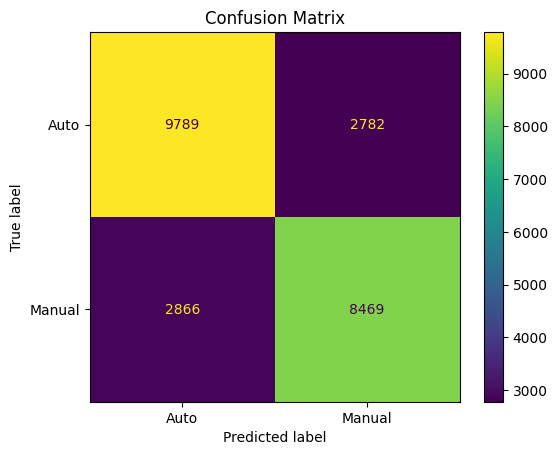

In [25]:
# 3.1 Confusion Matrix Analysis - Tasks - Present and visualize the confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_class, y_class_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Auto', 'Manual']
)

disp.plot()
plt.title('Confusion Matrix')
plt.show()

#### Present, visualize, and provide a detailed interpretation of the confusion matrix

The confusion matrix shows that the model correctly classified 9,789 Auto cars and 8,469 Manual cars.

There were also 2,782 Auto cars that were classified as Manual, and 2,866 Manual cars that were classified as Auto.

In general, the model performs reasonably well, although there are still some classification errors. The number of False Positives and False Negatives is quite similar, so there does not seem to be a large difference between the two types of errors.

------

#### Analyze the False Positives (FP) and False Negatives (FN), and discuss their implications

#### Analyze the False Positives (FP) and False Negatives (FN), and discuss their implications

The model produced 2,782 False Positives, which means that some Auto cars were predicted as Manual.

It also produced 2,866 False Negatives, which means that some Manual cars were predicted as Auto.

The two values are quite similar, so the model makes both types of errors at a similar rate. In this case, neither error type seems much more common than the other.

Since the target is the transmission type, the practical effect of both errors is similar: the model gives the wrong transmission category. Therefore, there is no clear reason at this stage to treat False Positives as much more serious than False Negatives, or the other way around.

------

### Questions

#### Which type of error is most critical in this context?

In this case, False Positives and False Negatives are both mistakes in predicting the transmission type.

The number of both errors is also quite similar, so there is no clear error type that is much more critical than the other.

------

#### In which regions does the model fail systematically?

From the confusion matrix, there is no clear class where the model fails much more than the other.

The number of mistakes for Auto and Manual cars is quite similar. To understand where the model fails more, we need to look at the features in more detail.

------

#### What insights can be derived from the analysis?

The model correctly classifies most of the cars, but it still makes a noticeable number of mistakes.

The errors are quite balanced between Auto and Manual cars, so the model does not seem to strongly prefer one class.

The confusion matrix gives a general view of the model performance, but more analysis is needed to understand why some cars are classified incorrectly.

------

## 3.2 Probability-Based Analysis

### Tasks

#### Compare predicted probabilities for correct vs incorrect predictions


In [26]:
# 3.2 Probability-Based Analysis - Tasks - Generate predicted probabilities

y_class_proba = cross_val_predict(
    classification_model,
    X_class,
    y_class,
    cv=skf,
    method='predict_proba'
)[:, 1]


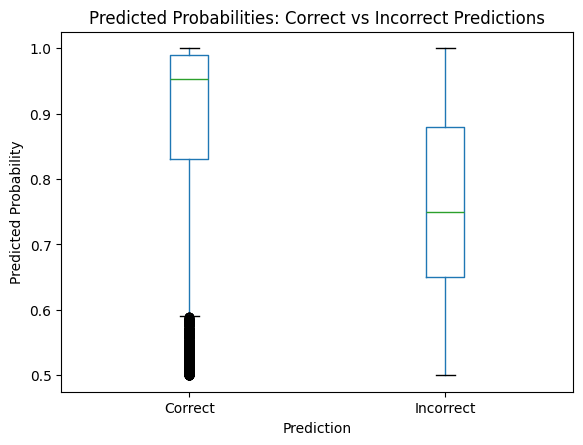

In [27]:
# 3.2 Probability-Based Analysis - Tasks - Compare predicted probabilities for correct vs incorrect predictions

correct_prediction = y_class == y_class_pred

prediction_confidence = np.where(
    y_class_pred == 1,
    y_class_proba,
    1 - y_class_proba
)

probability_df = pd.DataFrame({
    'Prediction': np.where(correct_prediction, 'Correct', 'Incorrect'),
    'Confidence': prediction_confidence
})

probability_df.boxplot(column='Confidence', by='Prediction', grid=False)

plt.xlabel('Prediction')
plt.ylabel('Predicted Probability')
plt.title('Predicted Probabilities: Correct vs Incorrect Predictions')
plt.suptitle('')
plt.show()


### Objective

The model is generally more confident when the prediction is correct. Correct predictions have a higher typical probability, while incorrect predictions have a lower typical probability.

However, there are also some incorrect predictions with very high confidence, sometimes close to 1.0. These are high-confidence errors, where the model is very confident even though the prediction is wrong.

This shows that a high predicted probability does not always mean that the prediction is correct.

------

### Summary and Conclusions

The probability analysis shows that correct predictions are usually made with higher confidence than incorrect predictions.

At the same time, the model still makes some errors with high confidence. This suggests that there are certain observations where the model is strongly confident in the wrong class.

------

## 3.3 Error as a Function of Features

### Tasks

#### Compare feature distributions for correct vs incorrect predictions

In [28]:
# 3.3 Error as a Function of Features - Prepare data for correct vs incorrect predictions

feature_error_df = pd.DataFrame({
    'Annual Income': car_sales_df['Annual Income'],
    'Prediction': np.where(
        y_class == y_class_pred,
        'Correct',
        'Incorrect'
    )
})

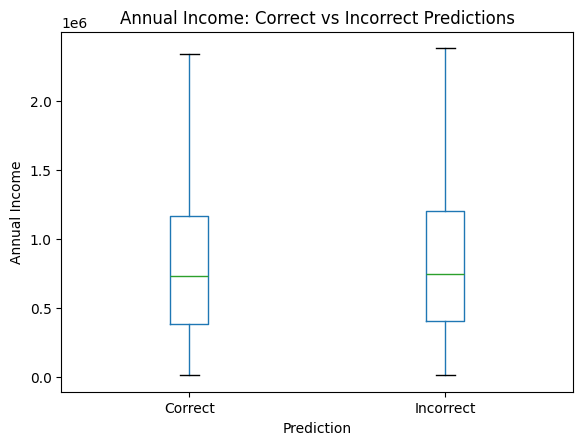

In [29]:
# 3.3 Error as a Function of Features - Tasks - Compare Annual Income for correct vs incorrect predictions

feature_error_df.boxplot(
    column='Annual Income',
    by='Prediction',
    grid=False,
    showfliers=False
)

plt.xlabel('Prediction')
plt.ylabel('Annual Income')
plt.title('Annual Income: Correct vs Incorrect Predictions')
plt.suptitle('')

plt.show()

The Annual Income distribution is very similar for correct and incorrect predictions. The median and the spread of the two groups are almost the same.

This suggests that Annual Income does not have a clear relationship with the classification errors. There is no clear income range where the model seems to make noticeably more errors.

------

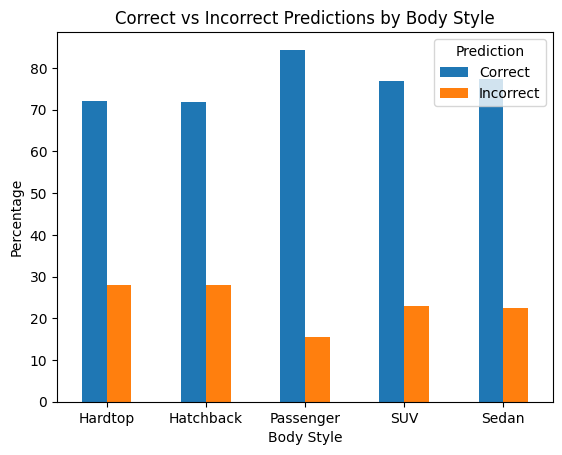

In [30]:
# 3.3 Error as a Function of Features - Tasks - Compare Body Style for correct vs incorrect predictions

body_style_errors = pd.crosstab(
    car_sales_df['Body Style'],
    feature_error_df['Prediction'],
    normalize='index'
) * 100

body_style_errors.plot(kind='bar')

plt.xlabel('Body Style')
plt.ylabel('Percentage')
plt.title('Correct vs Incorrect Predictions by Body Style')
plt.xticks(rotation=0)
plt.legend(title='Prediction')

plt.show()

The results are not the same for all Body Style categories.

Passenger cars have the lowest percentage of wrong predictions, while Hardtop and Hatchback have the highest.

SUV and Sedan are somewhere in the middle.

So, it seems that Body Style may affect how well the model classifies the cars, and some categories are a bit harder for the model.

This can also be compared with the EDA.

In the EDA, SUV and Hatchback were among the more common Body Style categories. Hatchback still showed a relatively high percentage of incorrect predictions.

This suggests that the higher error rate for Hatchback is not only related to having fewer observations.

------

### Objective

Identify regions prone to misclassification.

Annual Income does not show a clear difference between correct and incorrect predictions, so it does not seem to be a main reason for classification errors.

Body Style shows a clearer pattern. Hardtop and Hatchback have the highest percentage of incorrect predictions, while Passenger cars have the lowest.

This means that some Body Style categories are harder for the model to classify correctly.

A general conclusion from this analysis is that not every feature is equally useful for understanding the model errors. Annual Income does not seem to explain where the model fails, while Body Style gives more useful information.

One possible assumption that is not supported by the results is that the customer's income level would have a strong connection to the classification errors. In our results, this relationship is not clear.

Overall, the classification errors seem to be more related to characteristics of the car than to the customer's Annual Income.

------

## 3.4 Threshold Sensitivity Analysis

In [31]:
# 3.4 Threshold Sensitivity Analysis - Generate predicted probabilities

y_class_proba = cross_val_predict(
    classification_model,
    X_class,
    y_class,
    cv=skf,
    method='predict_proba'
)[:, 1]

### Evaluate performance across thresholds: 0.1, 0.2, ..., 0.9

In [32]:
# 3.4 Threshold Sensitivity Analysis - Evaluate Precision, Recall and F1 across thresholds

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results_thresholds = []

for threshold in thresholds:
    y_pred_threshold = (y_class_proba >= threshold).astype(int)

    precision = precision_score(y_class, y_pred_threshold)
    recall = recall_score(y_class, y_pred_threshold)
    f1 = f1_score(y_class, y_pred_threshold)

    results_thresholds.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results_df = pd.DataFrame(
    results_thresholds,
    columns=['Threshold', 'Precision', 'Recall', 'F1-score']
)

threshold_results_df

,Threshold,Precision,Recall,F1-score
0,0.1,0.629815,0.943361,0.755342
1,0.2,0.674785,0.894574,0.769289
2,0.3,0.709685,0.839788,0.769274
3,0.4,0.734171,0.783591,0.758076
4,0.5,0.751682,0.749096,0.750387
5,0.6,0.773347,0.715218,0.743148
6,0.7,0.817824,0.660609,0.730857
7,0.8,0.862508,0.585532,0.697530
8,0.9,0.908229,0.481959,0.629741


#### Precision, Recall and F1-score - Results

As the threshold increases, Precision increases while Recall decreases.

At low thresholds, the model identifies most of the Manual cars, but it also produces more False Positives. At higher thresholds, the model is more careful when predicting Manual, so Precision improves but more Manual cars are missed.

The F1-score is highest around thresholds 0.2-0.3, which gives the best balance between Precision and Recall among the tested thresholds.

------

#### Plot the Fβ-score as a function of β

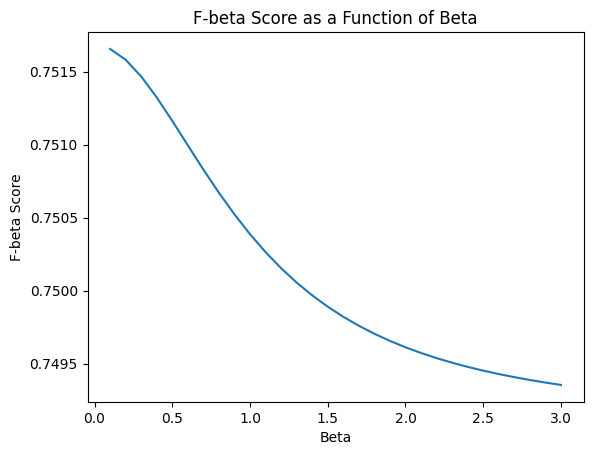

In [33]:
# 3.4 Threshold Sensitivity Analysis - Plot the Fβ-score as a function of β

from sklearn.metrics import fbeta_score

beta_values = np.arange(0.1, 3.1, 0.1)
fbeta_scores = []

y_pred_05 = (y_class_proba >= 0.5).astype(int)

for beta in beta_values:
    score = fbeta_score(y_class, y_pred_05, beta=beta)
    fbeta_scores.append(score)

plt.plot(beta_values, fbeta_scores)

plt.xlabel('Beta')
plt.ylabel('F-beta Score')
plt.title('F-beta Score as a Function of Beta')

plt.show()

The F-beta score changes only a little as beta increases.

This is because Precision and Recall are very close to each other at a threshold of 0.5.

Since Precision is slightly higher than Recall, the F-beta score decreases a little when more importance is given to Recall.

Overall, there is no big change in the F-beta score.

------

#### Matthews Correlation Coefficient (MCC)

In [34]:
# 3.4 Threshold Sensitivity Analysis - Matthews Correlation Coefficient (MCC)

from sklearn.metrics import matthews_corrcoef

y_pred_05 = (y_class_proba >= 0.5).astype(int)

mcc = matthews_corrcoef(y_class, y_pred_05)

print("MCC:", mcc)


MCC: 0.5260549101408435


The MCC value is about 0.53.

This means that the model performs better than random guessing, but it still makes quite a few mistakes.

The result is reasonable and matches what we saw in the confusion matrix, where most predictions were correct but there were still some errors.

------

#### Area Under the ROC Curve (AUC-ROC), including the ROC curve

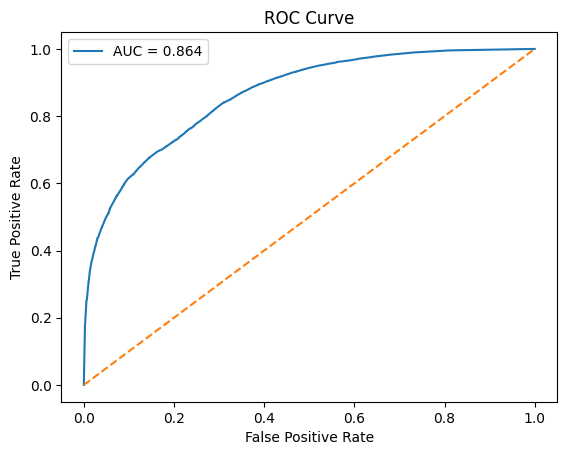

AUC-ROC: 0.8637747931405549


In [35]:
# 3.4 Threshold Sensitivity Analysis - Area Under the ROC Curve (AUC-ROC), including the ROC curve

from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_class, y_class_proba)

fpr, tpr, thresholds_roc = roc_curve(y_class, y_class_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

print("AUC-ROC:", auc)


The AUC-ROC value is about 0.864.

This means that the model is fairly good at separating between Auto and Manual cars.

The ROC curve is clearly above the random prediction line, which also shows that the model performs much better than random guessing.

According to the course material, an AUC of 0.5 represents performance similar to random guessing, while an AUC of 1 represents a perfect classifier. Since our AUC is 0.864, the model has a good ability to distinguish between the two classes.

The ROC curve also shows the trade-off between the True Positive Rate and the False Positive Rate at different thresholds.

Overall, the AUC result shows that the model has good classification ability, although it is still not perfect.

------


### Analysis

#### Trade-off between false positives and false negatives

In the course material, Recall is the same as the True Positive Rate (TPR):

TPR = TP / (TP + FN)

This means that when Recall is high, the model finds more of the actual Manual cars and produces fewer False Negatives.

The course material also defines the False Positive Rate (FPR) as:

FPR = FP / (FP + TN)

So, when the threshold is low, it is easier for a car to be classified as Manual. This increases Recall, but it can also increase the number of Auto cars that are incorrectly classified as Manual.

This can also be seen in our results. At threshold 0.1, Recall is very high (0.943), but Precision is lower (0.630). When the threshold increases, Precision improves while Recall decreases.

According to the course material, every point on the ROC curve represents a different classification threshold, and the ROC curve shows the trade-off between sensitivity and specificity.

In our case, thresholds around 0.2-0.3 give the highest F1-score. Since F1 combines Precision and Recall, this range gives a better balance between the two compared to very low or very high thresholds.

------

#### Identify stable and unstable operating regions

Based on our results, the thresholds around 0.2-0.5 seem to be the most stable region.

In this range, the F1-score stays around 0.75-0.77, and there is still a reasonable balance between Precision and Recall. Small changes in the threshold do not cause a very large change in the overall performance.

At higher thresholds, especially around 0.8-0.9, the model becomes less stable. Precision becomes high, but Recall drops from about 0.59 to 0.48, and the F1-score also decreases.

The course material explains that each point on the ROC curve represents a different classification threshold. Changing the threshold changes the balance between correctly detecting positive cases and creating False Positives. This is what we also see in our results.

So, for this model, the middle threshold range is more balanced and stable, while very high thresholds give less balanced results.

------

### Summary and Conclusions

The different analyses give a similar picture of the model performance.

The threshold results show that increasing the threshold improves Precision but reduces Recall. This is also reflected in the F-beta analysis, since the score changes according to the balance between Precision and Recall. In the course material, the F-beta score is described as a weighted combination of these two measures.

The MCC value of about 0.53 shows that the predictions have a reasonable connection with the true classes, but there are still classification errors.

At the same time, the AUC-ROC value of 0.864 shows that the model is generally good at separating Auto and Manual cars across different thresholds. The course material also explains that the ROC curve represents performance over different classification thresholds.

Overall, the model has good classification ability, but the final performance depends on the selected threshold. The range around 0.2-0.5 gives the most balanced results in our analysis.

------

## 3.5 Discussion

### The strengths and limitations of the evaluated models in relation to the data

The Random Forest model gave good classification results. The AUC-ROC was about 0.864, so the model can separate Auto and Manual cars quite well.

According to the course material, Random Forest builds many decision trees and uses majority vote for classification. The course also mentions that Random Forest can handle non-linear relationships and is robust to overfitting. :contentReference[oaicite:1]{index=1}

This fits our results because the classification errors were not explained by one simple feature. For example, Annual Income did not show a clear difference between correct and incorrect predictions, while some Body Style groups had more errors.

The model still has limitations. The confusion matrix showed both False Positives and False Negatives, and the MCC value of about 0.53 shows that the classification is not perfect.

Overall, Random Forest worked well on this data, but the error analysis shows that it performs better for some groups than for others.

------

### Key failure modes identified during the analysis

The errors do not show one clear failure pattern.

From the confusion matrix, the numbers of False Positives and False Negatives were quite similar, so the model does not mainly fail in one direction.

The probability analysis also showed that some incorrect predictions were made with high confidence. This means that high confidence does not always mean that the prediction is correct.

From the feature analysis, Annual Income did not explain the errors very well, while Body Style showed clearer differences between correct and incorrect predictions.

According to the course material, Random Forest can handle non-linear relationships. The course also shows that feature selection and feature engineering can help improve model performance when some features are not very useful.

Overall, the main failures seem to be related to specific observations and groups rather than to one general type of error.

------

### The relationship between model assumptions and observed performance

Random Forest does not require a linear relationship between the features and the target.

According to the course material, decision trees can handle non-linear relationships by splitting the feature space into different regions. Random Forest combines many such trees and uses majority vote for classification.

This fits our results because the errors were not explained by one simple pattern. For example, Annual Income did not show a clear difference between correct and incorrect predictions, while Body Style showed clearer differences between groups.

The AUC-ROC of 0.864 shows that the model was able to learn useful patterns in the data, but the MCC of about 0.53 and the remaining classification errors show that these patterns are not enough to classify every observation correctly.

Overall, the non-linear structure of Random Forest seems suitable for this data, but the results also show that the available features do not explain all the classification cases.

------

### The most significant insights derived from the study

One of the main insights is that the model performance should be examined using several measures and not only one result.

The AUC-ROC of 0.864 shows that the model separates the two classes quite well. At the same time, the confusion matrix and the MCC value of about 0.53 show that some classification errors still remain.

The feature analysis also showed some differences between the variables. Annual Income did not show a clear connection to the errors, while Body Style showed more noticeable differences between groups.

The threshold analysis showed that changing the threshold affects the balance between Precision and Recall. This is also connected to the course material, where the ROC curve represents model performance across different classification thresholds. :contentReference[oaicite:0]{index=0}

Overall, using the different analyses together gave a clearer picture of the model performance and helped show both its strengths and the areas where it can still be improved.

------

### Concrete recommendations for improving model performance and robustness in future work

The results show that not all features contribute in the same way. Annual Income did not show a clear connection to the classification errors, while Body Style showed clearer differences between correct and incorrect predictions.

Because of this, one possible improvement is to examine the features more carefully and check which of them really help the model. The course material explains that feature selection can remove irrelevant features and reduce the risk of overfitting.

The probability analysis also showed that some wrong predictions were made with high confidence. This means that the model can sometimes be very confident and still be wrong. For this reason, it may be useful to check the model settings and complexity.

This also connects to the course theory about overfitting and the bias-variance trade-off. The course material explains that a model that is too complex can have high variance, while the goal is to find a balance between bias and variance.

At the same time, Random Forest is a suitable model for this data because it can handle non-linear relationships and is considered robust to overfitting.

The threshold analysis gave another useful result. Around thresholds 0.2-0.3, the F1-score was the highest, while at very high thresholds Precision increased but Recall decreased strongly. This shows that the threshold should not be chosen automatically, but according to the balance we want between Precision and Recall.

Overall, the main improvements would be to examine the features more carefully, check the model complexity and choose the classification threshold according to the required balance between the different types of errors.

------

### Summary and Conclusions

The different analyses helped show the model performance from several directions.

The AUC-ROC value showed that the model can separate the two classes quite well, while the confusion matrix and the MCC showed that some classification errors still remain.

The probability analysis showed another interesting point, because some incorrect predictions were made with high confidence. This means that good overall performance does not mean that every individual prediction is reliable.

The feature analysis also showed that the errors are not equally related to all variables. Annual Income showed almost no clear connection to the errors, while Body Style showed more noticeable differences between groups.

The threshold analysis connected these results to the choice of decision threshold. Changing the threshold changed the balance between Precision and Recall, which is consistent with the course material where different ROC points represent different classification thresholds.

The results also fit the course description of Random Forest. The model can capture non-linear relationships and combines many trees, which may help explain its good overall performance, even though some difficult cases still remain.

Overall, the analyses suggest that the model is useful, but its performance depends on the type of observation, the available features and the selected threshold.

------

# 4 Final Reflection


### 1. Where does the model fail most?

The results show that the model does not fail in one single area.

In the regression analysis, the largest errors appeared mainly for some high-priced cars. These observations had large positive residuals, which means that the predicted price was much lower than the actual price. This also connects to the model comparison, where Linear Regression had the weakest results, while Decision Tree and Random Forest performed better.

According to the course material, Linear Regression assumes a linear relationship between the features and the target, while tree-based models can capture non-linear relationships. This can help explain why the tree-based models performed better on cases where the price behavior was more complex.

In the classification analysis, some Body Style groups, especially Hardtop and Hatchback, had more incorrect predictions. The probability analysis also showed that some incorrect predictions were made with high confidence.

Overall, the different analyses show that the main failures appear in more difficult or specific groups of observations rather than equally across the whole dataset.

------

### 2. Are failures due to data, model, or formulation?

The results suggest that the errors are mainly related to model limitations and to the selected features, rather than to clear data quality problems.

In the regression analysis, the extreme errors did not look like obvious incorrect values. Most of the largest errors appeared for expensive cars. Linear Regression also performed worse than Decision Tree and Random Forest.

According to the course material, Linear Regression assumes a linear relationship between the features and the target, while tree-based models can capture non-linear relationships. This may help explain the difference we saw between the models.

In the classification analysis, Annual Income did not show a clear connection to the errors, while Body Style showed clearer differences between groups. We also found some incorrect predictions with high confidence.

The course material on feature selection explains that removing irrelevant features and choosing useful features can help improve model performance.

The EDA also showed that the available data has some limitations, and not every factor that may affect the results is included in the dataset.

Because of this, some of the remaining errors may also be related to the available information and not only to the model itself.

Overall, there is no clear sign that data quality is the main problem. The results suggest that the model and the selected features are more important factors in the remaining errors.

------

### 3. What improvements would you propose?

One possible improvement is to look more carefully at the features we use.

In the regression part, Linear Regression had larger errors for some expensive cars, while the tree-based models gave better results. This suggests that the relationship between the features and the price is not always simple.

In the classification part, Annual Income did not show a clear connection to the errors, while Body Style showed more differences between correct and incorrect predictions.

The course material explains that feature selection can help remove irrelevant features, and that tree-based models are able to capture non-linear relationships.

Another improvement is to check the model settings and the classification threshold. In our results, the highest F1-score was around thresholds 0.2-0.3, so this range gave a better balance between Precision and Recall.

Overall, I would mainly focus on the features, the model settings, and the choice of threshold.

------

### 4. What insights did you gain in your analysis?

One of the main things I learned is that the overall model score does not tell the whole story.

In the regression part, the comparison between Linear Regression, Decision Tree and Random Forest showed that the model type has a clear effect on the results. The tree-based models performed better, which fits the course theory that trees can capture non-linear relationships.

The error analysis also helped show where the models have more difficulty. In regression, the larger errors appeared mainly for some expensive cars. In classification, some Body Style groups had more errors, and some wrong predictions were made with high confidence.

The threshold analysis showed that the final classification result also depends on the selected threshold. Changing the threshold changed the balance between Precision and Recall, which is also shown in the course material through the ROC curve.

Overall, the main insight is that model evaluation should combine several measures and error analyses. Looking at the errors, features and thresholds gave a better understanding of the model than using only one performance score.

------